In [1]:
import torch
import torch.nn as nn
import numpy as np
from DDBSCAN import Raster_DBSCAN
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
from Models import *
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors
from ModelSocial import LaneSocialLSTM
from Dataset import SocialLSTMDataset,social_lstm_collate
import h5py

# from TrainSocialLSTM import extract_trajectories,prepare_training_data
# times new roman font
plt.rcParams["font.family"] = "Times New Roman"
seed = 414
# np.random.seed(seed)
colors = np.random.rand(600, 3)
colors = np.concatenate([np.array([[0,0,0]]),colors],axis = 0)
colormap = mcolors.ListedColormap(colors)

In [2]:
import os
import numpy as np
import h5py
from tqdm import tqdm
import random
import glob

def process_traffic_context_data(
    source_dir,
    output_dir,
    input_frames=10,
    output_frames=12,
    train_samples=10000,
    val_samples=2000,
    seed=42
):
    """
    Process large traffic context data into smaller clips for Social-LSTM training
    
    Args:
        source_dir: Directory containing the original traffic context data
        output_dir: Directory to save processed data
        input_frames: Number of input frames per clip
        output_frames: Number of output frames per clip
        train_samples: Number of training samples to generate
        val_samples: Number of validation samples to generate
        seed: Random seed for reproducibility
    """
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    db = Raster_DBSCAN(Td_map_szie=(200,100), window_size=[3,9],eps = 1,min_samples=10)
    
    # Create output directories
    train_dir = os.path.join(output_dir, 'train')
    val_dir = os.path.join(output_dir, 'val')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    
    # Get list of traj_id files
    occupancy_files = glob.glob(os.path.join(source_dir, 'post_occ_label', '*.npy'))
    
    # Create H5PY files for training and validation
    train_h5_path = os.path.join(train_dir, 'social_lstm_data.h5')
    val_h5_path = os.path.join(val_dir, 'social_lstm_data.h5')
    print(f"Creating HDF5 files at {train_h5_path} and {val_h5_path}")
    with h5py.File(train_h5_path, 'w') as train_h5, h5py.File(val_h5_path, 'w') as val_h5:
        # Create datasets with maxshape parameter to allow resizing
        train_h5.create_dataset('traffic_context', # occupancy data
                              shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        
        train_h5.create_dataset('vehicle_id',
                                shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        
        train_h5.create_dataset('speed_data', 
                              shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip", 
                              compression_opts=4)
        train_h5.create_dataset('metadata', 
                              shape=(train_samples, 3),  # [file_idx, start_frame, num_vehicles]
                              maxshape=(None, 3), # Allow resizing
                              dtype=np.int32,
                              chunks=(100, 3))
        # Create same datasets for validation
        val_h5.create_dataset('traffic_context', 
                            shape=(val_samples, 200, input_frames + output_frames),
                            maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                            dtype=np.float32,
                            chunks=(1, 200, input_frames + output_frames),
                            compression="gzip",
                            compression_opts=4)
        val_h5.create_dataset('vehicle_id',
                                shape=(train_samples, 200, input_frames + output_frames),
                              maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                              dtype=np.float32,
                              chunks=(1, 200, input_frames + output_frames),
                              compression="gzip",
                              compression_opts=4)
        val_h5.create_dataset('speed_data', 
                            shape=(val_samples, 200, input_frames + output_frames),
                            maxshape=(None, 200, input_frames + output_frames), # Allow resizing
                            dtype=np.float32,
                            chunks=(1, 200, input_frames + output_frames),
                            compression="gzip",
                            compression_opts=4)
        val_h5.create_dataset('metadata', 
                            shape=(val_samples, 3),  # [file_idx, start_frame, num_vehicles]
                            maxshape=(None, 3), # Allow resizing
                            dtype=np.int32,
                            chunks=(100, 3))
        
        # Store source file names for reference
        train_h5.create_dataset('file_names', 
                              shape=(len(occupancy_files),),
                              dtype=h5py.special_dtype(vlen=str))
        val_h5.create_dataset('file_names', 
                            shape=(len(occupancy_files),),
                            dtype=h5py.special_dtype(vlen=str))
        
        for i, file_path in enumerate(occupancy_files):
            train_h5['file_names'][i] = os.path.basename(file_path)
            val_h5['file_names'][i] = os.path.basename(file_path)
        
        # Sample counter
        train_count = 0
        val_count = 0
        print( len(occupancy_files),'aa' )
        # Process each file and generate samples
        for file_idx, file_path in enumerate(tqdm(occupancy_files, desc="Processing files")):
            # Load trajectory ID data
            occupancy_data = np.load(file_path)
            
            # Try to load speed data if available
            try:
                speed_path = file_path.replace('traj_id_label', 'speed_label')
                speed_data = np.load(speed_path)
            except:
                # Create dummy speed data if not available
                speed_data = np.zeros_like(occupancy_data)
            
            traj_id_data = db.fit_predict(occupancy_data, Foreground_map=(occupancy_data == 1))  # Perform DBSCAN clustering
            # Get file shape
            lane_cells, time_span = occupancy_data.shape # 200, 100
            
            # Calculate number of possible starting frames
            max_start = time_span - (input_frames + output_frames) + 1
            
            if max_start <= 0:
                print(f"Skipping {file_path} - not enough frames")
                continue
            
            # Generate potential starting frames
            start_frames = list(range(0, max_start))
            random.shuffle(start_frames)
            
            # Select samples for this file
            file_train_count = min(100, len(start_frames) // 2)  # Limit samples per file
            file_val_count = min(20, len(start_frames) // 10)  # Limit validation samples per file
            # Generate training samples
            for i, start_frame in enumerate(start_frames[:file_train_count]):
                if train_count >= train_samples:
                    break
                    
                # Extract clip
                traj_id_clip = traj_id_data[:, start_frame:start_frame + input_frames + output_frames]
                occupancy_clip = occupancy_data[:, start_frame:start_frame + input_frames + output_frames]
                speed_clip = speed_data[:, start_frame:start_frame + input_frames + output_frames]
                
                # Count unique vehicles (excluding 0)
                unique_vehicles = np.unique(traj_id_clip)
                num_vehicles = len(unique_vehicles[unique_vehicles > 0])
                
                # Skip if no vehicles
                if num_vehicles == 0:
                    continue
                
                # Store data
                train_h5['vehicle_id'][train_count] = traj_id_clip
                train_h5['traffic_context'][train_count] = occupancy_clip
                train_h5['speed_data'][train_count] = speed_clip
                train_h5['metadata'][train_count] = [file_idx, start_frame, num_vehicles]
                
                train_count += 1
                
                # Print progress
                if train_count % 1000 == 0:
                    print(f"Generated {train_count}/{train_samples} training samples")
            
            # Generate validation samples
            for i, start_frame in enumerate(start_frames[file_train_count:file_train_count + file_val_count]):
                if val_count >= val_samples:
                    break
                    
                # Extract clip
                traj_id_clip = traj_id_data[:, start_frame:start_frame + input_frames + output_frames]
                occupancy_clip = occupancy_data[:, start_frame:start_frame + input_frames + output_frames]
                speed_clip = speed_data[:, start_frame:start_frame + input_frames + output_frames]
                
                # Count unique vehicles (excluding 0)
                unique_vehicles = np.unique(traj_id_clip)
                num_vehicles = len(unique_vehicles[unique_vehicles > 0])
                
                # Skip if no vehicles
                if num_vehicles == 0:
                    continue
                
                # Store data
                val_h5['vehicle_id'][val_count] = traj_id_clip
                val_h5['traffic_context'][val_count] = occupancy_clip
                val_h5['speed_data'][val_count] = speed_clip
                val_h5['metadata'][val_count] = [file_idx, start_frame, num_vehicles]
                
                val_count += 1
                
                # Print progress
                if val_count % 500 == 0:
                    print(f"Generated {val_count}/{val_samples} validation samples")
            
            # Break if we have enough samples
            if train_count >= train_samples and val_count >= val_samples:
                break
        
        # Update dataset sizes if we didn't generate enough samples
        if train_count < train_samples:
            print(f"Only generated {train_count}/{train_samples} training samples")
            train_h5['vehicle_id'].resize((train_count, 200, input_frames + output_frames))
            train_h5['traffic_context'].resize((train_count, 200, input_frames + output_frames))
            train_h5['speed_data'].resize((train_count, 200, input_frames + output_frames))
            train_h5['metadata'].resize((train_count, 3))
        
        if val_count < val_samples:
            print(f"Only generated {val_count}/{val_samples} validation samples")
            val_h5['vehicle_id'].resize((val_count, 200, input_frames + output_frames))
            val_h5['traffic_context'].resize((val_count, 200, input_frames + output_frames))
            val_h5['speed_data'].resize((val_count, 200, input_frames + output_frames))
            val_h5['metadata'].resize((val_count, 3))
    
    print(f"Successfully processed data:")
    print(f"  - Training samples: {train_count}")
    print(f"  - Validation samples: {val_count}")
    print(f"  - Saved to: {output_dir}")

    return train_h5_path, val_h5_path

In [3]:
db = Raster_DBSCAN(Td_map_szie=(200,100), window_size=[3,9],eps = 1,min_samples=10)

In [40]:
file_path = r'D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\train\post_occ_label\36_39_0_signal_1860.npy'
traffic_context = np.load(file_path)

In [41]:
id_map = db.fit_predict(traffic_context, Foreground_map=(traffic_context == 1))

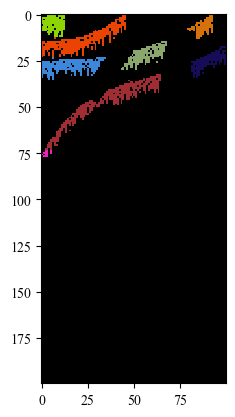

In [44]:
plt.imshow(id_map,cmap=colormap,interpolation='none')
plt.show()

In [ ]:
source_dir=r'D:\TimeSpaceDiagramDataset\EncoderDecoder_EvenlySampled_FreeflowAug_0914_5res_lanechange_signal\100_frame\train'
output_dir=r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset'
input_frames=10
output_frames=1
train_samples=20000
val_samples=4000
seed=714
process_traffic_context_data(source_dir, output_dir, input_frames, output_frames, train_samples, val_samples, seed)

In [4]:
class SocialLSTMDataset(Dataset):
    def __init__(self, h5_path, input_frames=10, output_frames=12, transform=None):
        """
        Dataset for Social LSTM training
        
        Args:
            h5_path: Path to HDF5 file containing data
            input_frames: Number of input frames
            output_frames: Number of output frames to predict
            transform: Optional transforms to apply
        """
        self.h5_path = h5_path
        self.input_frames = input_frames
        self.output_frames = output_frames
        self.transform = transform
        
        # Open HDF5 file for reading
        self.h5_file = h5py.File(h5_path, 'r')
        
        # Store useful information
        self.num_samples = self.h5_file['traffic_context'].shape[0]
        self.metadata = self.h5_file['metadata'][:]
        
        # Precompute indices of valid vehicle trajectories
        self.valid_trajectories = self._find_valid_trajectories()
        
    def _find_valid_trajectories(self):
        """Find all valid vehicle trajectories that have enough data for training"""
        valid_trajectories = []
        
        # For each sample
        for sample_idx in range(self.num_samples):
            # Get vehicle IDs for this sample
            vehicle_ids = self.h5_file['vehicle_id'][sample_idx]  # [lane_cells, total_frames]
            
            # Find unique vehicle IDs (excluding -1 which denotes empty cells)
            unique_ids = np.unique(vehicle_ids)
            unique_ids = unique_ids[unique_ids >= 0]
            
            for vehicle_id in unique_ids:
                # Check if this vehicle has data for all input frames
                valid = True
                
                # Check if vehicle appears in all input frames
                for t in range(self.input_frames):
                    if not np.any(vehicle_ids[:, t] == vehicle_id):
                        valid = False
                        break
                
                # Check if vehicle appears in at least first output frame
                if not np.any(vehicle_ids[:, self.input_frames] == vehicle_id):
                    valid = False
                
                if valid:
                    valid_trajectories.append((sample_idx, vehicle_id))
        
        return valid_trajectories
    
    def __len__(self):
        return len(self.valid_trajectories)
    
    def __getitem__(self, idx):
        # Get sample index and vehicle ID
        sample_idx, vehicle_id = self.valid_trajectories[idx]
        
        # Load data from HDF5 file
        vehicle_ids = self.h5_file['vehicle_id'][sample_idx]  # [lane_cells, total_frames]
        traffic_context = self.h5_file['traffic_context'][sample_idx]  # [lane_cells, total_frames]
        
        # Extract vehicle positions for input frames
        input_positions = np.zeros(self.input_frames, dtype=np.float32)
        for t in range(self.input_frames):
            # Find the front position (smallest index) where this vehicle appears
            positions = np.where(vehicle_ids[:, t] == vehicle_id)[0]
            if len(positions) > 0:
                input_positions[t] = np.min(positions)
                
        # Extract vehicle positions for output frames
        output_positions = np.zeros(self.output_frames, dtype=np.float32)
        output_masks = np.zeros(self.output_frames, dtype=np.float32)  # Mask for valid positions
        
        for t in range(self.output_frames):
            frame_idx = self.input_frames + t
            positions = np.where(vehicle_ids[:, frame_idx] == vehicle_id)[0]
            if len(positions) > 0:
                output_positions[t] = np.min(positions)
                output_masks[t] = 1.0  # Mark as valid, 1.0 if vehicle is present
                
        # Extract traffic context for input frames
        input_context = traffic_context[:, :self.input_frames].transpose(1, 0)  # [input_frames, lane_cells]
        
        # Convert to PyTorch tensors
        input_positions = torch.FloatTensor(input_positions)
        input_context = torch.FloatTensor(input_context)
        output_positions = torch.FloatTensor(output_positions)
        output_masks = torch.FloatTensor(output_masks)
        
        # Apply transforms if specified
        if self.transform:
            input_positions, input_context, output_positions, output_masks = self.transform(
                input_positions, input_context, output_positions, output_masks
            )
        """
        input_positions: [input_frames] : positions of the vehicle in the input frames
        input_context: [input_frames, lane_cells] : traffic context for input frames
        output_positions: [output_frames] : positions of the vehicle in the output frames
        output_masks: [output_frames] : 1.0 if vehicle is present, 0.0 if not

        """

        return input_positions, input_context, output_positions, output_masks
    
    def close(self):
        """Close the HDF5 file"""
        self.h5_file.close()
        
    def __del__(self):
        """Close the HDF5 file when the dataset is deleted"""
        self.close()

In [5]:
val_h5_path = r'D:\TimeSpaceDiagramDataset\SocialLSTMDataset\dataset\val\social_lstm_data.h5'
val_dataset = SocialLSTMDataset(
        h5_path=val_h5_path,
        input_frames=10,
        output_frames=1
    )
val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
    )

In [6]:
for batch in val_loader:
    input_positions, input_context, output_positions, output_masks = batch
    print(input_positions.shape, input_context.shape, output_positions.shape, output_masks.shape)
    break  # Remove this to process all batches

torch.Size([32, 10]) torch.Size([32, 10, 200]) torch.Size([32, 1]) torch.Size([32, 1])


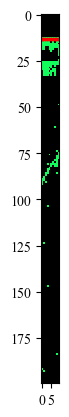

In [30]:
plt.imshow(input_context[20].cpu().numpy().T, cmap=colormap, interpolation='none')
# plot the input positions
plt.scatter(np.arange(10),input_positions[20].cpu().numpy(), color='red', marker='o', label='Input Positions', s = 3)
plt.show()

In [31]:
class SimplifiedLaneSocialLSTM(nn.Module):
    def __init__(self, 
                 hidden_size=64,
                 social_size=32,
                 neighborhood_size=16,
                 num_layers=1,
                 input_frames=10,
                 output_frames=12,
                 lane_cells=200,
                 dropout=0.2,
                 device='cuda' if torch.cuda.is_available() else 'cpu'):
        super(SimplifiedLaneSocialLSTM, self).__init__()
        self.device = device
        self.hidden_size = hidden_size
        self.social_size = social_size
        self.input_frames = input_frames
        self.output_frames = output_frames
        self.lane_cells = lane_cells
        self.neighborhood_size = neighborhood_size
        
        # Position embedding (for vehicle's front position)
        self.position_embedding = nn.Linear(1, hidden_size)
        
        # Social pooling embedding
        self.social_pooling_embedding = nn.Linear(neighborhood_size, social_size)
        
        # LSTM for sequence processing
        self.lstm = nn.LSTM(
            input_size=hidden_size + social_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Output decoder
        self.decoder_rnn = nn.LSTMCell(
            input_size=hidden_size,
            hidden_size=hidden_size
        )
        
        # Output layers - position and confidence
        self.output_position = nn.Linear(hidden_size, 1)
        self.output_confidence = nn.Linear(hidden_size, 1)
        
        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)
        self.to(device)
    
    def get_neighborhood(self, traffic_context, current_pos):
        """
        Extract traffic context neighborhood around current position
        
        Args:
            traffic_context: Binary lane occupancy [batch_size, lane_cells]
            current_pos: Current front position indices [batch_size]
            
        Returns:
            neighborhood: Extracted neighborhood [batch_size, neighborhood_size]
        """
        batch_size = traffic_context.shape[0]
        neighborhood = torch.zeros(batch_size, self.neighborhood_size, device=self.device)
        
        for b in range(batch_size):
            # Center position for this batch
            pos = current_pos[b].long()
            
            # Extract window around position
            start_idx = max(0, pos - self.neighborhood_size // 2)
            end_idx = min(self.lane_cells, pos + self.neighborhood_size // 2 + self.neighborhood_size % 2)
            width = end_idx - start_idx
            
            if width > 0:
                # Calculate offset to center the neighborhood window
                offset = max(0, self.neighborhood_size // 2 - pos)
                neighborhood[b, offset:offset+width] = traffic_context[b, start_idx:end_idx]
                
        return neighborhood
    
    def forward(self, vehicle_positions, traffic_context):
        """
        Forward pass with social pooling
        
        Args:
            vehicle_positions: Vehicle front positions [batch_size, input_frames]
            traffic_context: Binary traffic context [batch_size, input_frames, lane_cells]
            
        Returns:
            predicted_positions: Predicted positions [batch_size, output_frames]
            confidences: Prediction confidences [batch_size, output_frames]
        """
        batch_size = vehicle_positions.shape[0]
        
        # Prepare LSTM inputs
        lstm_inputs = torch.zeros(batch_size, self.input_frames, self.hidden_size + self.social_size, device=self.device)
        
        # Process each input time step
        for t in range(self.input_frames):
            # Current position
            pos = vehicle_positions[:, t].unsqueeze(1).float()  # [batch, 1]
            
            # Embed position
            pos_embedded = self.dropout(self.relu(self.position_embedding(pos)))
            
            # Get neighborhood for social pooling
            neighborhood = self.get_neighborhood(traffic_context[:, t], vehicle_positions[:, t])
            
            # Embed social context
            social_context = self.dropout(self.relu(self.social_pooling_embedding(neighborhood)))
            
            # Combine for LSTM input
            lstm_inputs[:, t] = torch.cat((pos_embedded, social_context), dim=1)
        
        # Process through LSTM
        lstm_out, (h_n, c_n) = self.lstm(lstm_inputs)
        
        # Initialize decoder state
        decoder_h = h_n[-1]  # [batch_size, hidden_size]
        decoder_c = c_n[-1]  # [batch_size, hidden_size]
        
        # Storage for predictions
        predicted_positions = []
        confidences = []
        
        # Current position starts as the last observed position
        current_pos = vehicle_positions[:, -1]
        
        # Generate predictions for future frames
        for t in range(self.output_frames):
            # Update LSTM state
            decoder_h, decoder_c = self.decoder_rnn(
                decoder_h,  # Previous hidden state used as input
                (decoder_h, decoder_c)
            )
            
            # Predict position and confidence
            pos_pred = self.output_position(decoder_h).squeeze(1)
            conf_pred = self.sigmoid(self.output_confidence(decoder_h)).squeeze(1)
            
            # Store predictions
            predicted_positions.append(pos_pred)
            confidences.append(conf_pred)
            
            # Update current position for next iteration (detached to prevent backprop through predictions)
            current_pos = pos_pred.detach()
        
        # Stack predictions
        predicted_positions = torch.stack(predicted_positions, dim=1)  # [batch_size, output_frames]
        confidences = torch.stack(confidences, dim=1)  # [batch_size, output_frames]
        
        return predicted_positions, confidences

In [41]:
def masked_mse_loss(predictions, targets, masks):
    """
    Masked MSE loss for trajectory prediction
    
    Args:
        predictions: Predicted positions [batch_size, output_frames]
        targets: Ground truth positions [batch_size, output_frames]
        masks: Binary masks for valid positions [batch_size, output_frames]
        
    Returns:
        loss: Masked MSE loss
    """
    # Compute squared error
    squared_error = (predictions - targets) ** 2
    
    # Apply mask
    masked_error = squared_error * masks
    
    # Sum over time and average over batch
    loss = masked_error.sum(dim=1) / (masks.sum(dim=1) + 1e-6)
    
    return loss.mean()

def social_trajectory_loss(predictions, targets, confidences, masks):
    """
    Combined loss function for position prediction and confidence
    
    Args:
        predictions: Predicted positions [batch_size, output_frames]
        targets: Ground truth positions [batch_size, output_frames]
        confidences: Prediction confidences [batch_size, output_frames]
        masks: Binary masks for valid positions [batch_size, output_frames]
        
    Returns:
        loss: Combined loss value
    """
    # Basic masked MSE loss
    mse_loss = masked_mse_loss(predictions, targets, masks)
    
    # Confidence-weighted error
    weighted_error = ((predictions - targets) ** 2) * confidences * masks
    confidence_weighted_error = weighted_error.sum(dim=1) / (masks.sum(dim=1) + 1e-6)
    confidence_weighted_error = confidence_weighted_error.mean()
    
    # Confidence calibration (higher confidence for lower error)
    neg_log_conf = -torch.log(confidences + 1e-6) * masks
    error_weight = torch.exp(-5.0 * ((predictions - targets) ** 2)) * masks
    confidence_calibration = (neg_log_conf * error_weight).sum(dim=1) / (masks.sum(dim=1) + 1e-6)
    confidence_calibration = confidence_calibration.mean()
    
    # Combined loss
    loss = mse_loss + 0.5 * confidence_weighted_error + 0.2 * confidence_calibration
    
    return loss, mse_loss, confidence_weighted_error, confidence_calibration

In [38]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SimplifiedLaneSocialLSTM(
    hidden_size=64,
    social_size=32,
    neighborhood_size=16,
    num_layers=1,
    input_frames=10,
    output_frames=1,
    lane_cells=200,
    dropout=0.2,
    device=device
)

In [43]:
predicted_positions, confidences = model(input_positions.to(device), input_context.to(device))

In [45]:
loss, mse_loss, confidence_weighted_error, confidence_calibration = social_trajectory_loss(predicted_positions, output_positions.to(device), confidences, output_masks.to(device))

In [47]:
loss.item()

1269.1358642578125

In [46]:
loss

tensor(1269.1359, device='cuda:0', grad_fn=<AddBackward0>)